# CoMoCut - EEG Processing 

**Author: Torsten Wüstenberg (CNSR) & Joel Grathwohl (ISSW)**

## Pipeline for EEG data during Sidecutting-maneuver

**Gereral analysis steps:**

1. *Combine Force Data and experimental Log*
2. *Select and load data for analysis*
3. *Set Montage, Annotations, Filter*
4. *Cut EEG data for analysis*
5. *Reject and interpolate artifactual channels*
6. *Re-reference*
7. *Artifact subspace reconstruction*
8. *Epoching*
9. *ICA-based artifact corection*
10. *Computing inverse solution*
11. *Extracting brain region-wise source strength time courses*
12. *Make and save table of sorce strength within defines time windows*
13. *Create Phase Lag for connectivity analysis*

### Preparations 

**Import libraries**

The analysis pipeline is based on the following libraries. In case of an error in the execution of this cell, probably one or more of the libraries is not installed. In this case, start a terminal in **ANACONDA.NAVIGATOR** *Environments>Terminal* and install the library in question using the command <span style='color: red'>*pip install [library name]*</span>.

In [3]:
import warnings                 # switch of pandas and mne warnings
warnings.simplefilter(action='ignore')

import requests
import os
import os.path as op
import time
import warnings

import mne

import numpy as np
import pandas as pd
import ipyfilechooser
import ipywidgets as widgets
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import pyprep
import math
import itertools
from datetime import datetime, timedelta
from datetime import datetime, timezone
#from playsound import playsound
from openpyxl import load_workbook
from mne.export import export_raw
from mne.stats import permutation_cluster_test, permutation_cluster_1samp_test

from typing import Optional, Union
from collections import defaultdict
from mne.datasets import fetch_fsaverage
from mne.evoked import combine_evoked
from mne.forward import make_forward_dipole
from mne.simulation import simulate_evoked
from mne.viz import circular_layout
from mne_connectivity import spectral_connectivity_epochs
from mne_connectivity.viz import plot_connectivity_circle
from mne_icalabel import label_components
from mne_icalabel.gui import label_ica_components
from asrpy import ASR

from scipy.stats import ttest_rel
from scipy.stats import pearsonr
from scipy import stats

from sklearn.feature_selection import mutual_info_regression
from itertools import combinations
from nilearn.image import index_img
from nilearn.plotting import plot_stat_map
from mne import read_evokeds
from mne.datasets import sample
from mne.minimum_norm import  make_inverse_operator, apply_inverse, read_inverse_operator, apply_inverse_epochs
from mpl_toolkits.axes_grid1 import make_axes_locatable

#from npeet.entropy_estimators import mi as kraskov_mi
import itertools

from random import randint
import pingouin
import pickle

import mne.coreg

%matplotlib qt

mne.set_log_level("ERROR")  # only show errors (no warnings or information messages)

In [8]:
print(mne.__version__)

1.12.1


In [10]:
wd = '/home/joel/Documents/Erhebung_HRvsLR/Koregistrierung'
fn = "A37_IC_left_epochs_amica.fif"
fp = wd + os.sep + fn
epochs = mne.read_epochs(fp, preload = True)

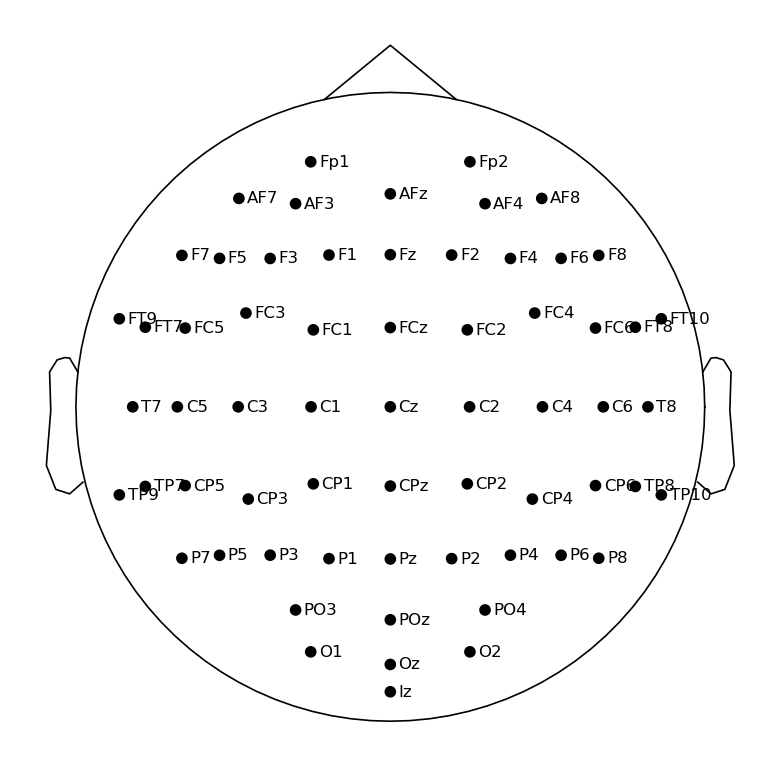

In [8]:
epochs.plot_sensors(show_names = True)
# ch_type="eeg"

# Running Freesurfer - Surface reconstruction

Log the bash commands for linux terminal here

# Setup BEM surface

In [1]:
subject = 'sub-01'
subjects_dir = '/home/joel/freesurfer_subjects'

In [2]:
subject = 'sub-01'
subjects_dir = '/home/joel/freesurfer_subjects'

# Generate BEM surfaces from FreeSurfer output
mne.bem.make_watershed_bem(
    subject=subject,
    subjects_dir=subjects_dir,
    overwrite=True
)

# Inspect the surfaces to check quality
mne.viz.plot_bem(
    subject=subject,
    subjects_dir=subjects_dir,
    orientation='coronal'
)

NameError: name 'mne' is not defined

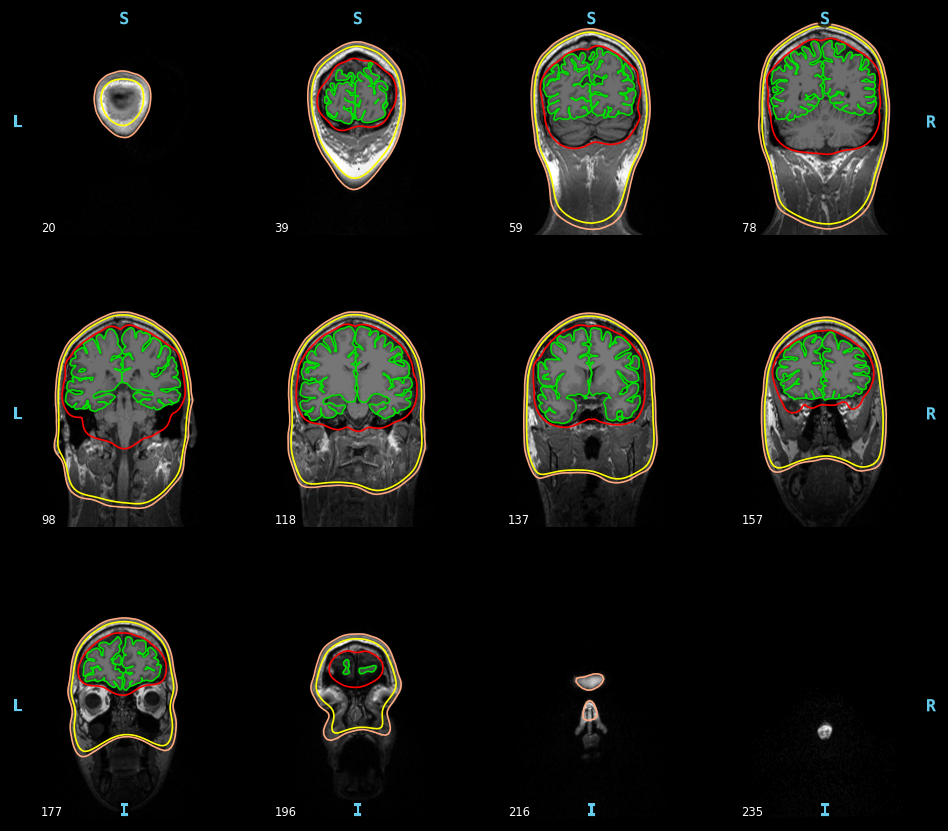

In [8]:
subject = 'sub-01'
subjects_dir = '/home/joel/freesurfer_subjects'

# Inspect the surfaces to check quality
mne.viz.plot_bem(
    subject=subject,
    subjects_dir=subjects_dir,
    orientation='coronal',
    brain_surfaces="pial"
)

# Import electrode positions
- With get_chanlocs_mni.csv
- Dictionary for channels with fiducials
- Make digital montage
- Check coordinate frame
- Apply montage

<DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 63 channels>
Coordinate frame: unknown


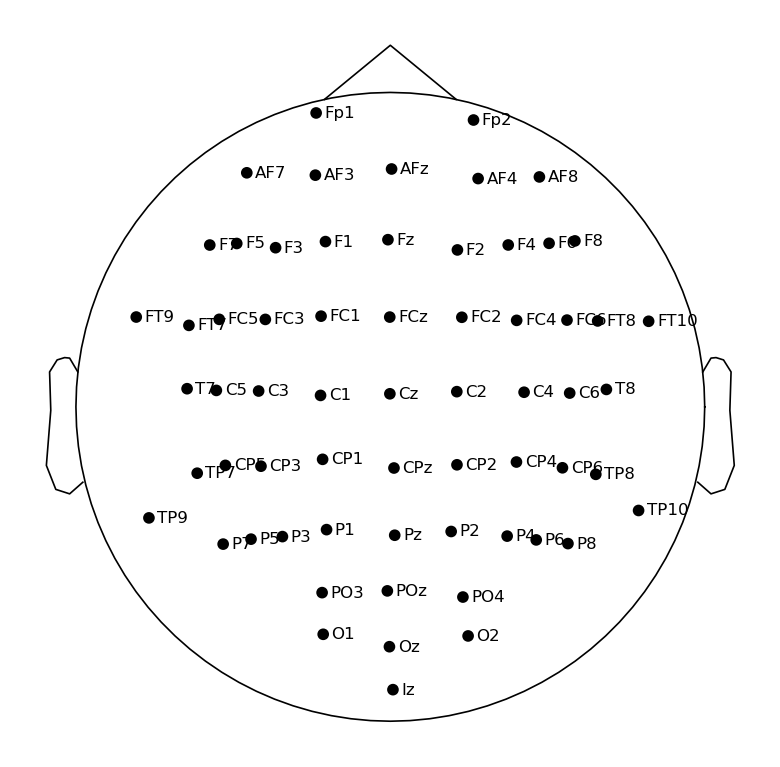

In [10]:
csv_path = "/home/joel/Documents/Erhebung_HRvsLR/Koregistrierung/get_chanlocs_mni.csv"

df = pd.read_csv(csv_path, comment='#')

fiducial_map = {'nas': 'nasion', 'lhj': 'lpa', 'rhj': 'rpa'}
non_eeg = {'HEOG', 'VEOG'}

fiducials = {}
ch_pos = {}
for _, row in df.iterrows():
    label = row['label']
    xyz = np.array([row['X'], row['Y'], row['Z']]) / 1000.0  # mm → m
    if label in fiducial_map:
        fiducials[fiducial_map[label]] = xyz
    elif label not in non_eeg:
        ch_pos[label] = xyz

montage = mne.channels.make_dig_montage(
    ch_pos=ch_pos,
    nasion=fiducials['nasion'],
    lpa=fiducials['lpa'],
    rpa=fiducials['rpa'],
)

print(montage)
print(f"Coordinate frame: {montage.get_positions()['coord_frame']}")

montage.plot()

In [13]:
epochs.set_montage(montage)

fn = "A37_IC_left_epochs_amica.fif"
fp = wd + os.sep + fn
epochs.save(fp, overwrite = True)

[PosixPath('/home/joel/Documents/Erhebung_HRvsLR/Koregistrierung/A37_IC_left_epochs_amica.fif')]

In [15]:
# Create trans file
fp = '/home/joel/Documents/Erhebung_HRvsLR/Koregistrierung/A37_IC_left_epochs_amica.fif'
mne.gui.coregistration(
    subject=subject,
    subjects_dir=subjects_dir,
    inst=fp
)

# Forward model
- Trans file
- source space -> src-file
- bem-model

In [24]:
wd = '/home/joel/Documents/Erhebung_HRvsLR/Koregistrierung'

# Load trans file from coregistration
trans = wd + os.sep + 'JG_trans.fif'

# Creat source space
src = mne.setup_source_space(
    subject=subject, 
    subjects_dir=subjects_dir,
    spacing="ico5", #oct5 = 1026 pt; ico4 = 2562 pt; oct6 = 4098 pt; ico5 = 10242 pt
    add_dist="patch"   
)

In [25]:
# BEM model
conductivity = (0.3, 0.006, 0.3)  # for three layers
bem_model = mne.make_bem_model(
    subject=subject,
    subjects_dir=subjects_dir,
    conductivity= conductivity
)

bem_solution = mne.make_bem_solution(bem_model)


In [26]:
fwd = mne.make_forward_solution(
    epochs.info,
    trans=trans,
    src=src,
    bem=bem_solution,
    eeg=True,
    mindist=5.0,
    n_jobs=-1,
    verbose=True,
)

Source space          : <SourceSpaces: [<surface (lh), n_vertices=135718, n_used=10242>, <surface (rh), n_vertices=138287, n_used=10242>] MRI (surface RAS) coords, subject 'sub-01', ~28.2 MiB>
MRI -> head transform : /home/joel/Documents/Erhebung_HRvsLR/Koregistrierung/JG_trans.fif
Measurement data      : instance of Info
Conductor model   : instance of ConductorModel
Accurate field computations
Do computations in head coordinates
Free source orientations

Read 2 source spaces a total of 20484 active source locations

Coordinate transformation: MRI (surface RAS) -> head
    0.999460 -0.012291 0.030473       0.79 mm
    0.003976 0.965825 0.259165      17.88 mm
    -0.032617 -0.258904 0.965352       4.39 mm
    0.000000 0.000000 0.000000       1.00

Read  63 EEG channels from info
Head coordinate coil definitions created.
Source spaces are now in head coordinates.

Employing the head->MRI coordinate transform with the BEM model.
BEM model instance of ConductorModel is now set up


Source

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  20 | elapsed:    2.5s remaining:    5.8s
[Parallel(n_jobs=-1)]: Done  11 out of  20 | elapsed:    2.7s remaining:    2.2s
[Parallel(n_jobs=-1)]: Done  16 out of  20 | elapsed:    2.8s remaining:    0.7s
[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:    2.9s finished



Finished.


In [27]:
# Save forward solution
mne.write_forward_solution("JG_sub-01-fwd.fif", fwd, overwrite = True)

In [11]:
fwd = mne.read_forward_solution('JG_sub-01-fwd.fif')

FileNotFoundError: File does not exist: "/home/joel/Documents/Erhebung_HRvsLR/EEG-Processing/JG_sub-01-fwd.fif"

# Inverse solution
1. Covariance
2. Inverse Operator
3. Source time course

In [9]:
subject = 'sub-01'
subjects_dir = '/home/joel/freesurfer_subjects'

In [30]:
def compute_covariance(epochs):
    
    # Compute rank directly from data
    rank = mne.compute_rank(
        epochs, 
        tol=1e-6,      # Tolerance for considering eigenvalue as zero
        tol_kind='relative'  # or 'absolute'
    )
    print(f"Rank of data: {rank}")

    # Use rank for covariance estimation
    noise_cov = mne.compute_covariance(
        epochs,
        tmin=-5.0, tmax=-3.0,  # here -5 to -3 is the baseline -> Participants standing still
        method='auto',
        rank=rank,  # ← Use computed rank
        verbose=True
    )

    # Plot
    #fig_cov, fig_spectra = mne.viz.plot_cov(noise_cov, epochs.info)

    return noise_cov

In [31]:
def make_inv(epochs, noise_cov, loose):
    inverse_operator = make_inverse_operator(
        epochs.info, 
        fwd, 
        noise_cov, 
        loose = loose, #default = 0.2 -> 0.0 == "fixed"
        depth = 0.8  #default
    )

    return inverse_operator

In [43]:
def apply_inv(epochs, method, snr):
    epo = epochs.set_eeg_reference("average", projection = True)
    evoked = epo.average()

    method = method  # could choose "dSPM", "MNE", "sLORETA", or "eLORETA" instead
    snr = snr          # 3 = very good (averaged, many trials); 2 = medium; 1 = bad (single trials)
    lambda2 = 1.0 / snr**2
    
    stc, residual = apply_inverse(
        evoked,
        inverse_operator,
        lambda2,
        method=method,
        pick_ori=None,
        return_residual=True,
        verbose=True,
    )

    return stc, residual

In [35]:
def visualize_brain(stc, subject, subjects_dir):
    vertno_max, time_max = stc.get_peak(hemi=None)
    
    surfer_kwargs = dict(
        hemi="both",
        surface="pial",
        subject=subject,
        subjects_dir=subjects_dir,
        #clim=dict(kind="value", lims=[1, 25, 50]),
        views="lateral",
        initial_time=0.0,
        time_unit="s",
        size=(800, 600),
        smoothing_steps=5,
    )
    brain = stc.plot(**surfer_kwargs)
    #brain.add_foci(
     #   vertno_max,
     #   coords_as_verts=True,
     #   hemi="rh",
     #   color="blue",
     #   scale_factor=0.6,
     #   alpha=0.5,
    #)
    brain.add_text(
        0.1, 0.9, f"dSPM, {epochs.filename}", font_size=6)

# The documentation website's movie is generated with:
# brain.save_movie(..., tmin=0.05, tmax=0.15, interpolation='linear',
#                  time_dilation=20, framerate=10, time_viewer=True)

## Run to get Source time course

In [44]:
# Noise covariance
noise_cov = compute_covariance(epochs)

inverse_operator = make_inv(epochs, noise_cov, 0.2)

method="MNE"
stc, residual = apply_inv(epochs, method = method, snr = 2.0)
#method: “MNE” | “dSPM” | “sLORETA” | “eLORETA”

#stc.save(f'JG_sub-01-stc_{method}', overwrite=True)

stc_crop=stc.crop(-1.0,0.0)
brain = visualize_brain(stc_crop, subject, subjects_dir)
brain


Rank of data: {'eeg': 57}
    Created an SSP operator (subspace dimension = 1)
    Setting small EEG eigenvalues to zero (without PCA)
Reducing data rank from 63 -> 57
Estimating covariance using SHRUNK
Done.
Estimating covariance using DIAGONAL_FIXED
    EEG regularization : 0.1
Done.
Estimating covariance using EMPIRICAL
Done.
Using cross-validation to select the best estimator.
    EEG regularization : 0.1
    EEG regularization : 0.1
    EEG regularization : 0.1
Number of samples used : 66066
log-likelihood on unseen data (descending order):
   shrunk: -126.124
   empirical: -126.213
   diagonal_fixed: -142.155
selecting best estimator: shrunk
[done]
Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 61
    Created the regularized inverter
    Created an SSP operator (subspace dimension = 1)
    Created the whitener using a noise covariance matrix with rank 57 (6 small eigenvalues omitted)
Applying inverse operator to "0.92 × IC

# Atlanten
- HCPMMP1 (gesamtes M1, S1 -> für uns unpraktisch)
- aparc_sub (kleinere Areale -> Könnte gut passen)


-> Noch installieren/einrichten